In [7]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

from utils import set_seed
set_seed(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 Random seed зафиксирован: 42


# Загрузка data_raw

In [8]:
df_features = pd.read_csv('data/raw_data.csv')

df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])
df_features = df_features.sort_values('timestamp').reset_index(drop=True)

print(f"Исходный размер данных: {df_features.shape}")

Исходный размер данных: (8760, 4)


# Временные и циклические признаки

In [9]:
# Извлекаем базовые компоненты времени прямо из timestamp
df_features['hour'] = df_features['timestamp'].dt.hour
df_features['weekday'] = df_features['timestamp'].dt.weekday
df_features['doy'] = df_features['timestamp'].dt.dayofyear

# Циклические признаки (Синус / Косинус) для непрерывного времени
df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)

df_features['weekday_sin'] = np.sin(2 * np.pi * df_features['weekday'] / 7)
df_features['weekday_cos'] = np.cos(2 * np.pi * df_features['weekday'] / 7)

df_features['doy_sin'] = np.sin(2 * np.pi * df_features['doy'] / 365.25)
df_features['doy_cos'] = np.cos(2 * np.pi * df_features['doy'] / 365.25)

# Флаги выходных и ночи
df_features['is_night'] = ((df_features['hour'] >= 22) | (df_features['hour'] <= 6)).astype(int)
df_features['is_weekend'] = (df_features['weekday'] >= 5).astype(int)

# Счетчик дней с начала симуляции (для улавливания макро-тренда)
df_features['days_elapsed'] = (df_features['timestamp'] - df_features['timestamp'].min()).dt.days

# Удаляем вспомогательные линейные колонки, оставляя только Sin/Cos
df_features = df_features.drop(columns=['hour', 'weekday', 'doy'])

# Лаги, разницы и скользящие окна

In [10]:
shifted_consumption = df_features['consumption'].shift(1)

#  ВРЕМЕННЫЕ ЛАГИ
lags = [1, 2, 4, 12, 24, 48, 168]
for lag in lags:
    df_features[f'lag_{lag}h'] = df_features['consumption'].shift(lag)

# РАЗНИЦЫ (DIFFS) 
diffs = [1, 6, 12, 24, 48, 168]
for d in diffs:
    df_features[f'diff_{d}h'] = shifted_consumption.diff(d)

# ПРОЦЕНТНЫЕ ИЗМЕНЕНИЯ
df_features['pct_change_1h'] = shifted_consumption.pct_change(1)
df_features['pct_change_24h'] = shifted_consumption.pct_change(24)

# СКОЛЬЗЯЩИЕ ОКНА
windows = [3, 6, 12, 24, 48, 168]

for w in windows:
    roll = shifted_consumption.rolling(window=w, min_periods=1)
    
    df_features[f'{w}h_mean'] = roll.mean()
    df_features[f'{w}h_std'] = roll.std()
    df_features[f'{w}h_min'] = roll.min()
    df_features[f'{w}h_max'] = roll.max()
    
    if w in [24, 168]:
        df_features[f'{w}h_q25'] = roll.quantile(0.25)
        df_features[f'{w}h_q75'] = roll.quantile(0.75)

# ЭКСПОНЕНЦИАЛЬНЫЕ СРЕДНИЕ
df_features['ema_12'] = shifted_consumption.ewm(span=12).mean()
df_features['ema_24'] = shifted_consumption.ewm(span=24).mean()
df_features['ema_168'] = shifted_consumption.ewm(span=168).mean()

# Target Encoding

In [11]:


train_split_idx = int(len(df_features) * 0.8)
train_subset = df_features.iloc[:train_split_idx]

map_day_type = train_subset.groupby('day_type')['consumption'].mean()
map_season = train_subset.groupby('season')['consumption'].mean()

df_features['day_type_enc'] = df_features['day_type'].map(map_day_type)
df_features['season_enc'] = df_features['season'].map(map_season)

global_mean = train_subset['consumption'].mean()
df_features['day_type_enc'] = df_features['day_type_enc'].fillna(global_mean)
df_features['season_enc'] = df_features['season_enc'].fillna(global_mean)

df_features = df_features.drop(columns=['day_type', 'season'])

# Очистка и Сохранение результата

In [12]:


df_features = df_features.replace([np.inf, -np.inf], np.nan)

df_features = df_features.dropna().reset_index(drop=True)

feature_cols = [col for col in df_features.columns if col not in ['timestamp', 'consumption']]

print(f"Итоговый размер данных: {df_features.shape}")

file_path = 'data/features.csv'
df_features.to_csv(file_path, index=False)

print(f"/n Данные с признаками сохранены в {file_path}")


Итоговый размер данных: (8591, 59)
/n Данные с признаками сохранены в data/features.csv


# Матрица корреляций

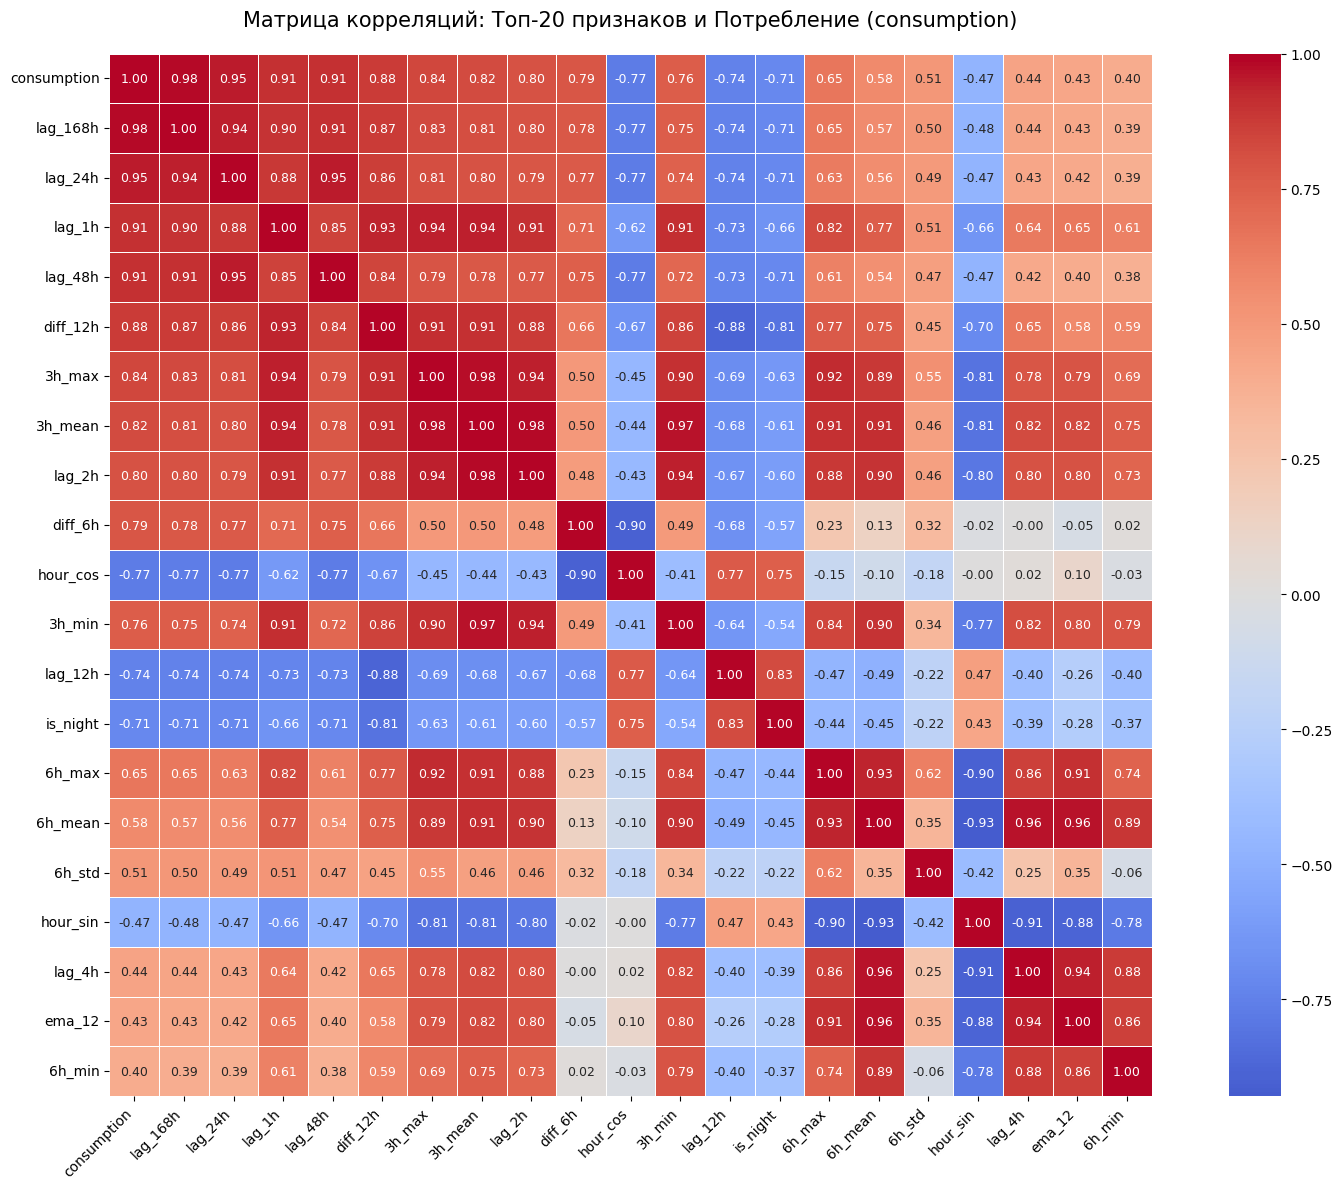

In [14]:

numeric_df = df_features.drop(columns=['timestamp'])
full_corr = numeric_df.corr()

corr_with_target = full_corr['consumption'].abs().sort_values(ascending=False)
top_20_features = corr_with_target.index[:21] # 20 признаков + сам 'consumption'

top_corr_matrix = full_corr.loc[top_20_features, top_20_features]

plt.figure(figsize=(16, 12))
sns.heatmap(
    top_corr_matrix, 
    annot=True,              
    fmt=".2f",               
    cmap='coolwarm',          
    center=0,                 
    square=True,             
    linewidths=0.5,          
    annot_kws={"size": 9}    
)

plt.title("Матрица корреляций: Топ-20 признаков и Потребление (consumption)", 
          fontsize=15,  pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.savefig('data/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
